In [1]:
exec(open(__import__('pathlib').Path(__vsc_ipynb_file__).parent.parent / 'src' / 'display_html.py').read())

## Schapiro et al. (2017) — Full Figure Reproduction

This notebook reproduces all three main result figures from:

> Schapiro, A. C., Turk-Browne, N. B., Botvinick, M. M., & Norman, K. A. (2017). Complementary learning systems within the hippocampus. *Phil. Trans. R. Soc. B*, 372, 20160049.

**Testing procedure (§2.d):** present each item in isolation — no previous item, no plus-phase target — and let activity settle for 80 cycles. Record at cycle 20 (initial response) and cycle 80 (settled response).

**Three experiments:**
- **Fig 2** — Pair structure: 8 items in 4 pairs (AB/CD/EF/GH); with vs without statistical learning
- **Fig 3** — Community structure: 15 items in 5 communities × 3 items; MSP/TSP dissociation
- **Fig 4** — Associative inference: 9 items in 3 triads; CA3 recurrence enables transitivity

Note: the paper averages over 500 network seeds. We use `N_REPS` (default 20) for reasonable run time.

In [2]:
import sys
from pathlib import Path

DIR_SRC = str((Path(__vsc_ipynb_file__).parent.parent / 'src').resolve())
DIR_VIZ = (Path(__vsc_ipynb_file__).parent.parent / 'visualizations').resolve()
DIR_MAN = (Path(__vsc_ipynb_file__).parent.parent / 'manuscript').resolve()
sys.path.insert(0, DIR_SRC)

import numpy as np
import rsatoolbox
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from model import M_Hip
from tasks import T_PairDataset, T_CommunityGraphDataset, T_CommunityGraphEnv, T_ChainDataset
from simulate import run_simulation
from util import F_extract_rsa, F_pattern_sim_by_mask
from visualize import plot_rsa_heatmap, plot_sim_bars, plot_output_prob, plot_community_graph

# Number of network initializations to average over.
# Schapiro (2017) §2.a.v: 500. We use 20 for practical run time.
N_REPS = 20

print('Setup complete.')

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Setup complete.


In [3]:
# Testing procedure (Schapiro 2017 §2.d): model.run_evaluation(item_idx) and
# model.run_evaluation_all() are M_Hip methods defined in model.py.
# Analysis helpers: F_extract_rsa, F_pattern_sim_by_mask imported from util.py.
# Similarity computation uses rsatoolbox.rdm.calc_rdm(method='correlation') throughout.
print('Analysis helpers ready.')

Analysis helpers ready.


## Figure 2 — Pair Structure

Schapiro (2017) §3.a: 8 items in 4 fixed pairs (AB/CD/EF/GH).

**Two conditions** (Fig 2 top and bottom rows):
- **Episodic** (`interleaved=True`): pairs are presented in isolation — A→B, C→D, etc. — with no B→A or cross-pair links. Only TSP can learn (direct pair associations). This is the "without statistical learning" condition.
- **Statistical** (`interleaved=False`): sequential walk — A→B (deterministic), B→A_other (uniform over 3 remaining pairs). Both MSP and TSP learn. MSP detects the forward asymmetry; TSP binds individual A→B episodes.

**Metrics:**
- RSA matrices: 8×8 pairwise Pearson r between CA1 representations (initial and settled)
- Pattern similarity: mean Pearson r for same-pair items vs cross-pair (shuffled baseline)
- Output probability: P(ECout_partner > 0.5) after each epoch — learning curve over 10 epochs

**Expected results (Schapiro 2017 Fig. 2):**
- Both conditions produce CA1 similarity above baseline for same-pair items
- Statistical condition shows smoother community-like RSA structure in CA1 (MSP contribution)
- Episodic condition shows sharper pair-specific patterns (TSP dominates)
- Output probability increases over epochs, faster for episodic (TSP: fast lr=0.4)

In [4]:
# --- Fig 2: Pair structure training + testing ---
# Schapiro (2017) §3.a: 8 items in 4 pairs (AB/CD/EF/GH)
# 80 trials/epoch × 10 epochs × N_REPS seeds × 2 conditions

N_ITEMS_PAIR  = 8
N_EPOCHS_PAIR = 10
N_TRIALS_PAIR = 80
N_PAIRS       = 4

# Template instance for structural methods
ds_pair = T_PairDataset(n_steps=N_TRIALS_PAIR, n_pairs=N_PAIRS)

# eval_fn returns (initial_mats, settled_mats) = m.run_evaluation_all()
# Schapiro (2017) §2.d: initial = cycle 20, settled = cycle 80
# results['eval'][r][ep]:
#   ep=0   → before any training
#   ep>0   → after epoch ep

print('Running episodic (without SL)...')
ep_results = run_simulation(
    lambda: M_Hip(n_cond=N_ITEMS_PAIR),
    lambda: T_PairDataset(n_steps=N_TRIALS_PAIR, n_pairs=N_PAIRS, interleaved=True),
    n_epochs=N_EPOCHS_PAIR, n_reps=N_REPS,
    eval_fn=lambda m: m.run_evaluation_all(),
    seed=0,
)

print('Running statistical (with SL)...')
sl_results = run_simulation(
    lambda: M_Hip(n_cond=N_ITEMS_PAIR),
    lambda: T_PairDataset(n_steps=N_TRIALS_PAIR, n_pairs=N_PAIRS, interleaved=False),
    n_epochs=N_EPOCHS_PAIR, n_reps=N_REPS,
    eval_fn=lambda m: m.run_evaluation_all(),
    seed=0,
)

# Settled ECout per rep per epoch, including pre-training (ep=0)
# Shape: (N_REPS, N_EPOCHS_PAIR+1, N_ITEMS_PAIR, N_ITEMS_PAIR)
ep_ecout = np.stack([
    np.stack([ep_results['eval'][r][ep][1]['ecout'] for ep in range(N_EPOCHS_PAIR + 1)])
    for r in range(N_REPS)
])
sl_ecout = np.stack([
    np.stack([sl_results['eval'][r][ep][1]['ecout'] for ep in range(N_EPOCHS_PAIR + 1)])
    for r in range(N_REPS)
])

# Post-training RSA matrices: initial = cycle 20, settled = cycle 80
ep_init_rsa = F_extract_rsa(ep_results, lambda e: e[-1][0])
ep_sett_rsa = F_extract_rsa(ep_results, lambda e: e[-1][1])
sl_init_rsa = F_extract_rsa(sl_results, lambda e: e[-1][0])
sl_sett_rsa = F_extract_rsa(sl_results, lambda e: e[-1][1])

print('Done.')


Running episodic (without SL)...
Running statistical (with SL)...
Done.


In [5]:
# --- Fig 2 metrics ---
epochs = np.arange(0, N_EPOCHS_PAIR + 1)   # epochs 0 (pre-training) through 10
masks  = ds_pair.rsa_masks()               # {'same': ..., 'cross': ...}

ep_init_sim = F_pattern_sim_by_mask(ep_init_rsa, masks)
ep_sett_sim = F_pattern_sim_by_mask(ep_sett_rsa, masks)
sl_init_sim = F_pattern_sim_by_mask(sl_init_rsa, masks)
sl_sett_sim = F_pattern_sim_by_mask(sl_sett_rsa, masks)

# 5 output probability curves: A→B, B→A, A→A, B→B, incorrect
# ecout_arr: (N_REPS, N_EPOCHS+1, n_items, n_items) — includes pre-training epoch 0
ep_prob = ds_pair.output_prob_detail_by_epoch(ep_ecout)
sl_prob = ds_pair.output_prob_detail_by_epoch(sl_ecout)

for cond, init_sim, sett_sim in [('Episodic',    ep_init_sim, ep_sett_sim),
                                   ('Statistical', sl_init_sim, sl_sett_sim)]:
    m_i, _    = init_sim['ca1']['same']
    m_s, se_s = sett_sim['ca1']['same']
    m_c, se_c = sett_sim['ca1']['cross']
    print(f'{cond}: CA1 initial={m_i:.3f}  settled same={m_s:.3f}±{se_s:.3f}  cross={m_c:.3f}±{se_c:.3f}')


Episodic: CA1 initial=0.176  settled same=0.212±0.035  cross=0.274±0.025
Statistical: CA1 initial=0.557  settled same=0.572±0.034  cross=0.193±0.028


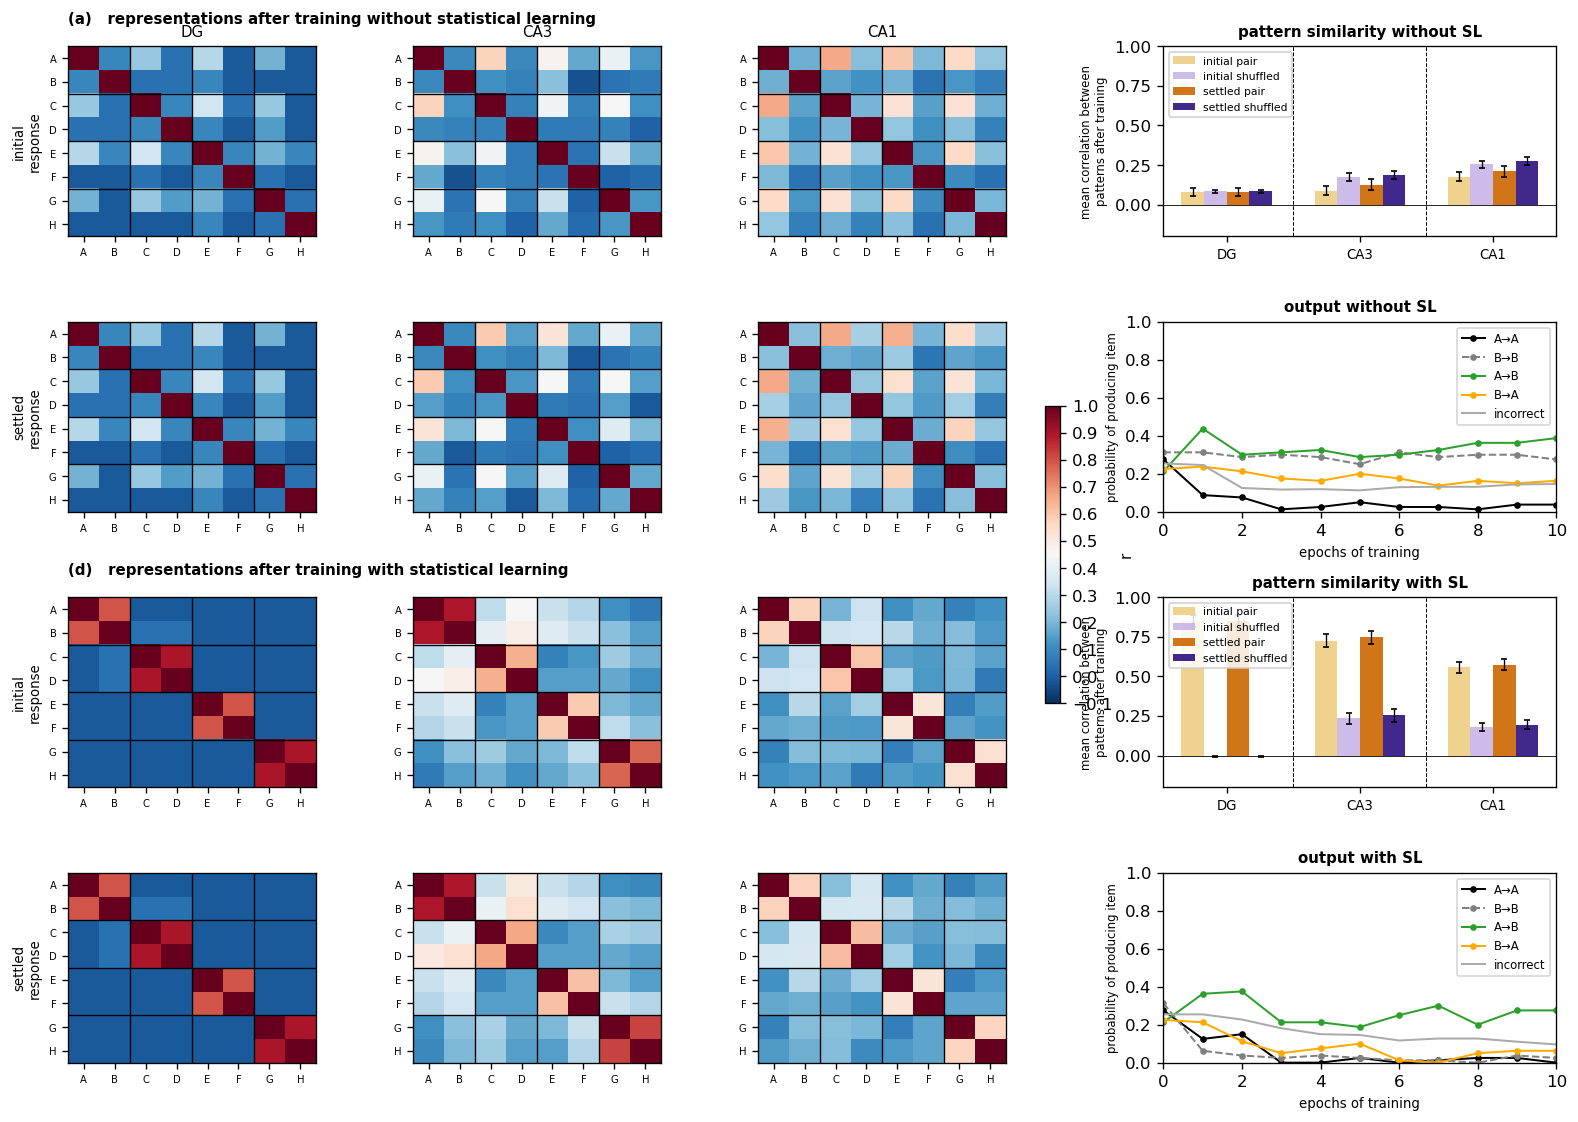

In [6]:
# --- Plot Figure 2 — Pair Structure (Schapiro 2017 Fig. 2) ---
# Layout: 4 rows × 4 cols (matches paper)
# Rows 0-1: without SL (initial / settled response)
# Rows 2-3: with SL    (initial / settled response)
# Cols 0-2: DG / CA3 / CA1   Col 3: sim bars (top) + output prob (bottom)

ITEMS_PAIR = list('ABCDEFGH')
layers     = ['dg', 'ca3', 'ca1']

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35,
                         width_ratios=[1, 1, 1, 1.5])

cond_list = [
    (ep_init_rsa, ep_sett_rsa, ep_init_sim, ep_sett_sim, ep_prob, 0, 'without SL'),
    (sl_init_rsa, sl_sett_rsa, sl_init_sim, sl_sett_sim, sl_prob, 2, 'with SL'),
]

rsa_axes_all = []
last_im      = None

for init_rsa, sett_rsa, init_sim, sett_sim, prob, r0, sfx in cond_list:
    for ci, layer in enumerate(layers):
        ax_i = fig.add_subplot(gs[r0, ci])
        last_im = plot_rsa_heatmap(
            ax_i, init_rsa[layer].mean(0), N_PAIRS, 2,
            title=layer.upper() if r0 == 0 else None,
            vmin=-0.1, vmax=1.0, cmap='RdBu_r')
        ax_i.set_xticks(range(N_ITEMS_PAIR))
        ax_i.set_xticklabels(ITEMS_PAIR, fontsize=6)
        ax_i.set_yticks(range(N_ITEMS_PAIR))
        ax_i.set_yticklabels(ITEMS_PAIR, fontsize=6)
        if ci == 0:
            ax_i.set_ylabel('initial\nresponse', fontsize=8)
        rsa_axes_all.append(ax_i)

        ax_s = fig.add_subplot(gs[r0 + 1, ci])
        last_im = plot_rsa_heatmap(
            ax_s, sett_rsa[layer].mean(0), N_PAIRS, 2,
            vmin=-0.1, vmax=1.0, cmap='RdBu_r')
        ax_s.set_xticks(range(N_ITEMS_PAIR))
        ax_s.set_xticklabels(ITEMS_PAIR, fontsize=6)
        ax_s.set_yticks(range(N_ITEMS_PAIR))
        ax_s.set_yticklabels(ITEMS_PAIR, fontsize=6)
        if ci == 0:
            ax_s.set_ylabel('settled\nresponse', fontsize=8)
        rsa_axes_all.append(ax_s)

    ax_sim = fig.add_subplot(gs[r0, 3])
    bar_specs = [
        ('initial pair',     init_sim, 'same',  '#EDCD82'),
        ('initial shuffled', init_sim, 'cross', '#C8B4E8'),
        ('settled pair',     sett_sim, 'same',  '#CC6600'),
        ('settled shuffled', sett_sim, 'cross', '#2B1080'),
    ]
    x_g, w_b = np.arange(len(layers)), 0.17
    for j, (lbl, sim_d, key, col) in enumerate(bar_specs):
        off = (j - (len(bar_specs) - 1) / 2) * w_b
        for i, layer in enumerate(layers):
            m, se = sim_d[layer][key]
            ax_sim.bar(x_g[i] + off, m, width=w_b, color=col,
                       alpha=0.9, label=lbl if i == 0 else '')
            ax_sim.errorbar(x_g[i] + off, m, yerr=se, fmt='none',
                            color='k', capsize=2, lw=0.8)
    ax_sim.set_xticks(x_g)
    ax_sim.set_xticklabels(['DG', 'CA3', 'CA1'], fontsize=8)
    for xi in [0.5, 1.5]:
        ax_sim.axvline(xi, color='k', lw=0.6, ls='--')
    ax_sim.set_ylim(-0.2, 1.0)
    ax_sim.axhline(0, color='k', lw=0.5)
    ax_sim.set_ylabel('mean correlation between\npatterns after training', fontsize=7)
    ax_sim.set_title(f'pattern similarity {sfx}', fontsize=9, fontweight='bold')
    ax_sim.legend(fontsize=6.5, loc='upper left', framealpha=0.85)

    ax_out = fig.add_subplot(gs[r0 + 1, 3])
    curve_specs = [
        ('A→A', 'A_A', 'black',   '-',  'o'),
        ('B→B', 'B_B', 'gray',    '--', 'o'),
        ('A→B', 'A_B', '#2CA02C', '-',  'o'),
        ('B→A', 'B_A', '#FFAA00', '-',  'o'),
        ('incorrect', 'incorrect', '#AAAAAA', '-', None),
    ]
    for lbl, key, col, ls, mk in curve_specs:
        kw = dict(color=col, linestyle=ls, label=lbl, linewidth=1.2)
        if mk:
            kw.update(marker=mk, markersize=3)
        ax_out.plot(epochs, prob[key], **kw)
    ax_out.set_ylim(0, 1.0)
    ax_out.set_xlim(0, N_EPOCHS_PAIR)
    ax_out.set_xticks(range(0, N_EPOCHS_PAIR + 1, 2))
    ax_out.set_xlabel('epochs of training', fontsize=8)
    ax_out.set_ylabel('probability of producing item', fontsize=7)
    ax_out.set_title(f'output {sfx}', fontsize=9, fontweight='bold')
    ax_out.legend(fontsize=7)

cb = plt.colorbar(last_im, ax=rsa_axes_all, fraction=0.015, pad=0.04,
                   ticks=np.round(np.arange(-0.1, 1.05, 0.1), 1))
cb.set_label('r', fontsize=9)

# Condition titles above each 2-row RSA block
# Axes order: gs[0,0], gs[1,0], gs[0,1], gs[1,1], gs[0,2], gs[1,2] = indices 0-5
#             gs[0,3]=6, gs[1,3]=7; then gs[2,0]=8 (DG initial, with SL)
ax_r0 = fig.axes[0]   # DG initial, without SL
ax_r2 = fig.axes[8]   # DG initial, with SL
for ax_ref, title_txt in [
    (ax_r0, '(a)   representations after training without statistical learning'),
    (ax_r2, '(d)   representations after training with statistical learning'),
]:
    pos = ax_ref.get_position()
    fig.text(pos.x0, pos.y1 + 0.015, title_txt,
             ha='left', va='bottom', fontsize=9, fontweight='bold',
             transform=fig.transFigure)

plt.savefig(DIR_VIZ / 'Schapiro2017_Fig2_pair.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 3 — Community Structure

Schapiro (2017) §3.b: 15 items in 5 communities × 3 items each.

The community graph has a ring topology: communities form a cycle, and the boundary item of each community connects to the first item of the next community. This produces an asymmetry between **internal** items (connected only within their own community) and **boundary** items (connected to an adjacent community).

**Why this matters:**
- MSP accumulates statistical regularities: items that often co-occur (same community) develop similar CA1 representations. The 15×15 RSA matrix should show 5 warm blocks on the diagonal.
- TSP binds each individual episode: CA3 forms distinct attractors, preserving episode-specific detail.

**Metrics:**
- RSA heatmaps: 15×15 Pearson r (initial vs settled; DG/CA3/CA1)
- Output probability: internal (degree 2) vs boundary (degree 3) items across epochs
  - Boundary items have extra between-community edges → slightly harder to predict correctly
- Settled-minus-initial CA1 heatmap: which items' representations change most through settling?
- Pattern similarity bars: within-community vs between-community (analogous to Fig 2b)

**Expected results (Schapiro 2017 Fig. 3):**
- RSA matrix shows 5 diagonal blocks (community clusters) after training
- Internal items reach slightly higher output probability (more predictable neighbors)
- Settling (20→80 cycles) improves output probability for all items (CA3 pattern completion)

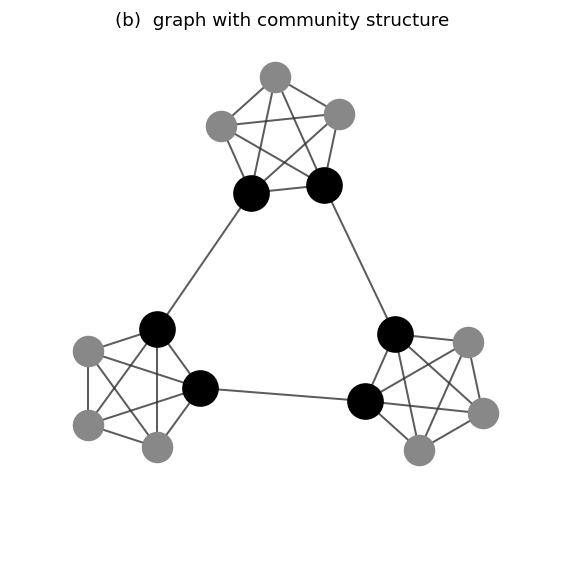

In [7]:
# Community graph — monochrome style matching Schapiro 2017 Fig. 3b
# Black nodes = boundary (inter-community edges); gray = internal
_env   = T_CommunityGraphEnv(n_communities=3, items_per_community=5)
A_comm = (_env._transition_matrix > 0).astype(int)

fig, ax = plt.subplots(figsize=(5, 5))
plot_community_graph(ax, A_comm, 3, 5, monochrome=True,
                     title='(b)  graph with community structure')
plt.tight_layout()
plt.show()


In [8]:
# --- Fig 3: Community structure training + testing ---
# Schapiro (2017) §3.b: 15 items in 3 communities × 5 items
# chance = 5/15 = 0.33 (items_per_community / n_items)
# 60 trials/epoch × 10 epochs × N_REPS seeds

N_ITEMS_COMM  = 15
N_COMM        = 3   # Schapiro (2017) Fig. 3: 3 communities
IPC           = 5   # Schapiro (2017) Fig. 3: 5 items per community
N_EPOCHS_COMM = 10
N_TRIALS_COMM = 60  # Schapiro (2017) §3.b

ds_comm = T_CommunityGraphDataset(n_steps=N_TRIALS_COMM, n_communities=N_COMM, items_per_community=IPC)
A_comm  = (T_CommunityGraphEnv(n_communities=N_COMM, items_per_community=IPC)
            ._transition_matrix > 0).astype(int)

# eval_fn returns (initial_mats, settled_mats) = m.run_evaluation_all()
# Schapiro (2017) §2.d: initial = cycle 20, settled = cycle 80
# results['eval'][r][ep]:
#   ep=0   → before any training
#   ep>0   → after epoch ep

print('Running community structure experiment...')
comm_results = run_simulation(
    lambda: M_Hip(n_cond=N_ITEMS_COMM),
    lambda: T_CommunityGraphDataset(
        n_steps=N_TRIALS_COMM, n_communities=N_COMM, items_per_community=IPC,
    ),
    n_epochs=N_EPOCHS_COMM, n_reps=N_REPS,
    eval_fn=lambda m: m.run_evaluation_all(),
    seed=0,
)

# Post-training RSA: initial = cycle 20, settled = cycle 80
comm_init_rsa = F_extract_rsa(comm_results, lambda e: e[-1][0])
comm_sett_rsa = F_extract_rsa(comm_results, lambda e: e[-1][1])

# Settled ECout per rep per epoch, including pre-training (ep=0)
# Shape: (N_REPS, N_EPOCHS_COMM+1, N_ITEMS_COMM, N_ITEMS_COMM)
comm_ecout = np.stack([
    np.stack([comm_results['eval'][r][ep][1]['ecout'] for ep in range(N_EPOCHS_COMM + 1)])
    for r in range(N_REPS)
])

print('Done.')


Running community structure experiment...
Done.


In [9]:
# --- Fig 3 metrics ---
epochs        = np.arange(0, N_EPOCHS_COMM + 1)   # epochs 0 (pre-training) through 10
# output_prob_by_epoch operates on comm_ecout (N_REPS, N_EPOCHS+1, n_items, n_items)
comm_prob      = ds_comm.output_prob_by_epoch(comm_ecout)     # {'internal':..., 'boundary':...}
comm_masks_det = ds_comm.rsa_masks_detail()                   # 4-category detail masks

comm_init_sim = F_pattern_sim_by_mask(comm_init_rsa, comm_masks_det)
comm_sett_sim = F_pattern_sim_by_mask(comm_sett_rsa, comm_masks_det)

print('CA1 pattern similarity (4 categories, initial vs settled):')
for k in ['within_internal', 'within_boundary', 'across_boundary', 'across_other']:
    m_i, _    = comm_init_sim['ca1'][k]
    m_s, se_s = comm_sett_sim['ca1'][k]
    print(f'  {k:25s}: initial={m_i:.3f}  settled={m_s:.3f} ± {se_s:.3f}')

print(f'\nChance = {IPC/N_ITEMS_COMM:.2f}')
print(f'Epoch {N_EPOCHS_COMM}: internal={comm_prob["internal"][-1]:.3f}  boundary={comm_prob["boundary"][-1]:.3f}')


CA1 pattern similarity (4 categories, initial vs settled):
  within_internal          : initial=0.468  settled=0.492 ± 0.027
  within_boundary          : initial=0.483  settled=0.483 ± 0.026
  across_boundary          : initial=0.188  settled=0.189 ± 0.052
  across_other             : initial=0.078  settled=0.095 ± 0.026

Chance = 0.33
Epoch 10: internal=0.361  boundary=0.333


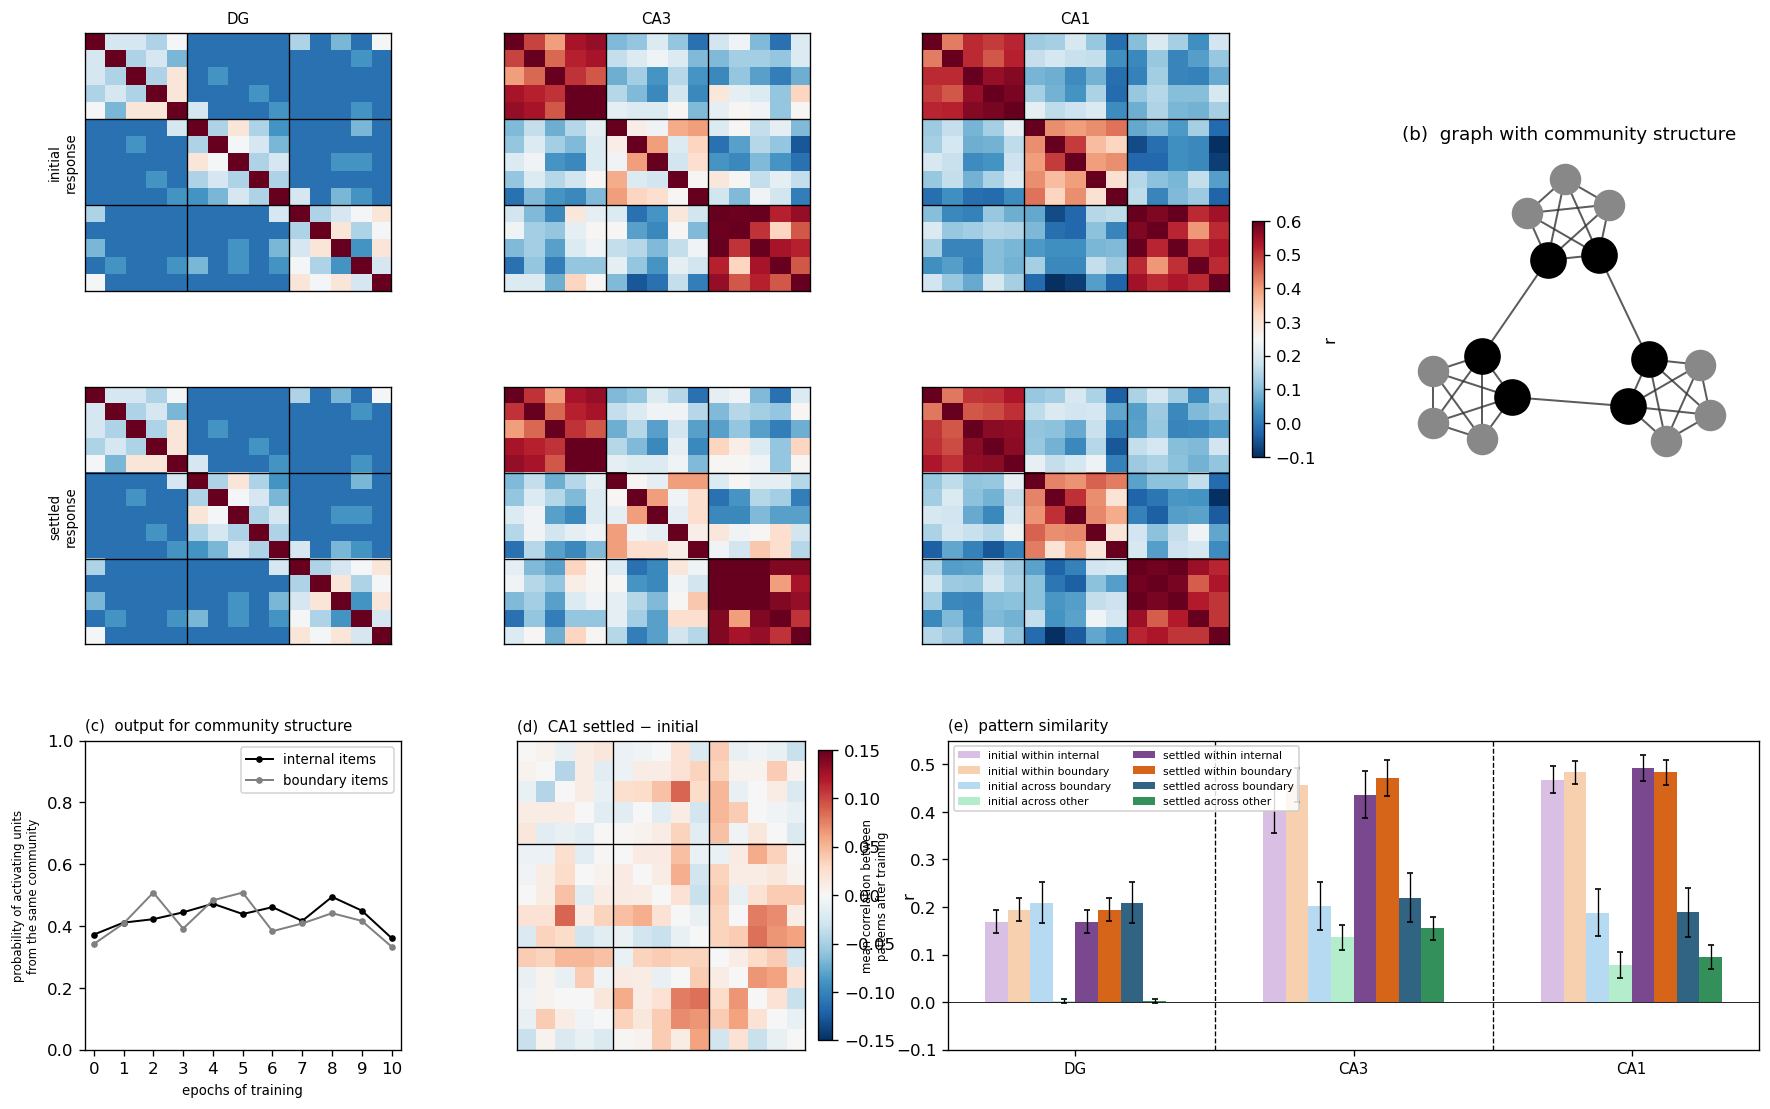

In [10]:
# --- Plot Figure 3 — Community Structure (Schapiro 2017 Fig. 3) ---
# Layout matches paper:
#   (a) 2×3 RSA grid   (b) community graph (monochrome)
#   (c) output prob    (d) CA1 diff heatmap   (e) 8-bar sim
#
# GridSpec 3 rows × 4 cols:
#   Rows 0-1, Cols 0-2: (a) 6 RSA panels  (vmin=-0.1, vmax=0.6, RdBu_r)
#   Rows 0-1, Col 3:    (b) community graph
#   Row 2, Col 0:       (c) output probability
#   Row 2, Col 1:       (d) CA1 settled − initial heatmap (new)
#   Row 2, Cols 2-3:    (e) pattern similarity (8 bars: initial×4 + settled×4)

layers = ['dg', 'ca3', 'ca1']

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(3, 4, figure=fig,
                         height_ratios=[1, 1, 1.2],
                         width_ratios=[1, 1, 1, 1.2],
                         hspace=0.35, wspace=0.35)

# (a) RSA panels — Schapiro 2017 Fig. 3a: vmin=-0.1, vmax=0.6, cmap='RdBu_r'
rsa_axes = []
last_rsa_im = None
for snap_row, (snap_lbl, rsa_dict) in enumerate([('initial\nresponse', comm_init_rsa),
                                                   ('settled\nresponse', comm_sett_rsa)]):
    for col_idx, layer in enumerate(layers):
        ax = fig.add_subplot(gs[snap_row, col_idx])
        last_rsa_im = plot_rsa_heatmap(
            ax, rsa_dict[layer].mean(0), N_COMM, IPC,
            title=layer.upper() if snap_row == 0 else None,
            ylabel=snap_lbl if col_idx == 0 else None,
            vmin=-0.1, vmax=0.6, cmap='RdBu_r')
        rsa_axes.append(ax)

plt.colorbar(last_rsa_im, ax=rsa_axes, fraction=0.01, pad=0.02,
             ticks=np.round(np.arange(-0.1, 0.65, 0.1), 1), label='r')

# (b) Community graph — monochrome: black=boundary, gray=internal
ax_b = fig.add_subplot(gs[0:2, 3])
plot_community_graph(ax_b, A_comm, N_COMM, IPC, monochrome=True,
                     title='(b)  graph with community structure')

# (c) Output probability — internal (black) vs boundary (gray); Schapiro 2017 Fig. 3c
ax_c = fig.add_subplot(gs[2, 0])
ax_c.plot(epochs, comm_prob['internal'], color='black', lw=1.2, marker='o', markersize=3,
           label='internal items')
ax_c.plot(epochs, comm_prob['boundary'], color='gray',  lw=1.2, marker='o', markersize=3,
           label='boundary items')
ax_c.set_ylim(0, 1.0)
ax_c.set_xlim(-0.3, N_EPOCHS_COMM + 0.3)
ax_c.set_xticks(range(0, N_EPOCHS_COMM + 1))
ax_c.set_xlabel('epochs of training', fontsize=8)
ax_c.set_ylabel('probability of activating units\nfrom the same community', fontsize=7)
ax_c.set_title('(c)  output for community structure', fontsize=9, loc='left')
ax_c.legend(fontsize=8)

# (d) CA1 settled − initial heatmap — Schapiro 2017 Fig. 3d
ax_d = fig.add_subplot(gs[2, 1])
diff_mat = comm_sett_rsa['ca1'].mean(0) - comm_init_rsa['ca1'].mean(0)
im_diff  = ax_d.imshow(diff_mat, cmap='RdBu_r', vmin=-0.15, vmax=0.15, aspect='auto')
for k in range(1, N_COMM):
    ax_d.axhline(k * IPC - 0.5, color='k', lw=0.8)
    ax_d.axvline(k * IPC - 0.5, color='k', lw=0.8)
ax_d.set_xticks([])
ax_d.set_yticks([])
ax_d.set_title('(d)  CA1 settled − initial', fontsize=9, loc='left')
plt.colorbar(im_diff, ax=ax_d, label='r', fraction=0.046, pad=0.04,
             ticks=[-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15])

# (e) Pattern similarity — 8 bars: initial (light) + settled (dark) × 4 categories
# Colors match paper Fig. 3e legend: purple=within_internal, orange=within_boundary,
# blue=across_boundary, green=across_other; light=initial, dark=settled
ax_e = fig.add_subplot(gs[2, 2:4])
bar_specs = [
    ('initial within internal',  comm_init_sim, 'within_internal',  '#D4B8E0'),
    ('initial within boundary',  comm_init_sim, 'within_boundary',  '#F5CBA7'),
    ('initial across boundary',  comm_init_sim, 'across_boundary',  '#AED6F1'),
    ('initial across other',     comm_init_sim, 'across_other',     '#ABEBC6'),
    ('settled within internal',  comm_sett_sim, 'within_internal',  '#6C3483'),
    ('settled within boundary',  comm_sett_sim, 'within_boundary',  '#D35400'),
    ('settled across boundary',  comm_sett_sim, 'across_boundary',  '#1A5276'),
    ('settled across other',     comm_sett_sim, 'across_other',     '#1E8449'),
]
x_g = np.arange(len(layers))
w_b = 0.65 / len(bar_specs)
for j, (lbl, sim_d, key, col) in enumerate(bar_specs):
    off = (j - (len(bar_specs) - 1) / 2) * w_b
    for i, layer in enumerate(layers):
        m, se = sim_d[layer][key]
        ax_e.bar(x_g[i] + off, m, width=w_b, color=col, alpha=0.9,
                 label=lbl if i == 0 else '')
        ax_e.errorbar(x_g[i] + off, m, yerr=se, fmt='none', color='k', capsize=2, lw=0.8)
for xi in [0.5, 1.5]:
    ax_e.axvline(xi, color='k', lw=0.8, ls='--')
ax_e.set_xticks(x_g)
ax_e.set_xticklabels(['DG', 'CA3', 'CA1'], fontsize=9)
ax_e.set_ylim(-0.1, 0.55)
ax_e.axhline(0, color='k', lw=0.5)
ax_e.set_ylabel('mean correlation between\npatterns after training', fontsize=7)
ax_e.set_title('(e)  pattern similarity', fontsize=9, loc='left')
ax_e.legend(fontsize=6.5, ncol=2, loc='upper left', framealpha=0.85)

plt.savefig(DIR_VIZ / 'Schapiro2017_Fig3_community.png', dpi=150, bbox_inches='tight')
plt.show()


## Figure 4 — Associative Inference

Schapiro (2017) §3.c: 9 items in 3 triads (ABC/DEF/GHI).

The model is trained only on **direct pairs**: A→B and B→C for each triad. The test asks whether it can complete **transitive pairs**: A→C (two hops). This requires inference — the model never sees A and C together during training.

**Why CA3 is needed for transitivity:**
- Without CA3 recurrence: the model stores only direct associations (A→B and B→C). When A is presented at test, ECout can activate B but cannot then use B to activate C.
- With CA3 recurrence: after training, A's CA3 attractor (TSP) encodes A's context including its connection to B. Through recurrent settling, CA3 can bridge the two-hop A→B→C path, producing CA1 patterns that include C-like components.

**Two conditions:**
- **Full model**: normal M_Hip with CA3→CA1 connection
- **No CA3 (lesion)**: CA3→CA1 weights zeroed; only DG→CA1 via MSP (W_ECin→CA1)

**Metrics:**
- RSA heatmaps: 9×9 Pearson r showing whether A and C cluster together (transitive inference)
- Pattern similarity: direct (A↔B, B↔C) vs transitive (A↔C) vs unrelated
- Output probability: P(ECout_C > 0.5 | input=A) for full vs lesion model

In [11]:
# --- Chain (associative inference) task constants ---
N_ITEMS_CHAIN  = 9
N_TRIADS       = 3
IPC_CHAIN      = 3
N_EPOCHS_CHAIN = 10
N_TRIALS_CHAIN = 60

# Template instance for structural methods (rsa_masks, output_prob, direct_pairs, trans_pairs)
ds_chain = T_ChainDataset(n_steps=N_TRIALS_CHAIN, n_triads=N_TRIADS)

print('Direct pairs (trained):', ds_chain.direct_pairs)
print('Transitive pairs (test):', ds_chain.trans_pairs)
print(f'n_items={ds_chain.n_items}')

Direct pairs (trained): [(0, 1), (1, 2), (3, 4), (4, 5), (6, 7), (7, 8)]
Transitive pairs (test): [(0, 2), (3, 5), (6, 8)]
n_items=9


In [12]:
# --- Fig 4: Associative inference training + testing ---
# Two training amounts: one-exposure (1 epoch) and full training (10 epochs)
# Two eval conditions: with CA3 recurrence (normal) and without (no_recurrence=True)
#
# eval_both evaluates both simultaneously at each checkpoint:
#   returns ((init_rec, sett_rec), (init_norec, sett_norec))
# results['eval'][r][ep] = ((init_rec, sett_rec), (init_norec, sett_norec))
#   ep=0 → pre-training; ep>0 → after epoch ep
#   [0] = with recurrence, [1] = without; [0/1][0] = initial, [0/1][1] = settled

eval_both = lambda m: (
    m.run_evaluation_all(no_recurrence=False),
    m.run_evaluation_all(no_recurrence=True),
)

print('Running one-exposure (1 epoch)...')
chain_1exp = run_simulation(
    lambda: M_Hip(n_cond=N_ITEMS_CHAIN),
    lambda: T_ChainDataset(n_steps=N_TRIALS_CHAIN, n_triads=N_TRIADS),
    n_epochs=1, n_reps=N_REPS,
    eval_fn=eval_both,
    seed=0,
)

print('Running full training (10 epochs)...')
chain_full = run_simulation(
    lambda: M_Hip(n_cond=N_ITEMS_CHAIN),
    lambda: T_ChainDataset(n_steps=N_TRIALS_CHAIN, n_triads=N_TRIADS),
    n_epochs=N_EPOCHS_CHAIN, n_reps=N_REPS,
    eval_fn=eval_both,
    seed=0,
)

# RSA: last epoch, settled (cycle 80)
# snap_fn: e = evals[r] (list of epoch snaps); e[-1] = last epoch snap
# e[-1][0][1] = with-rec settled;  e[-1][1][1] = no-rec settled
chain_1exp_rec_rsa   = F_extract_rsa(chain_1exp, lambda e: e[-1][0][1])
chain_1exp_norec_rsa = F_extract_rsa(chain_1exp, lambda e: e[-1][1][1])
chain_full_rec_rsa   = F_extract_rsa(chain_full, lambda e: e[-1][0][1])
chain_full_norec_rsa = F_extract_rsa(chain_full, lambda e: e[-1][1][1])

# Settled ECout for output_prob: (N_REPS, n_items, n_items), last epoch only
chain_1exp_rec_ecout   = np.stack([chain_1exp['eval'][r][-1][0][1]['ecout'] for r in range(N_REPS)])
chain_1exp_norec_ecout = np.stack([chain_1exp['eval'][r][-1][1][1]['ecout'] for r in range(N_REPS)])
chain_full_rec_ecout   = np.stack([chain_full['eval'][r][-1][0][1]['ecout'] for r in range(N_REPS)])
chain_full_norec_ecout = np.stack([chain_full['eval'][r][-1][1][1]['ecout'] for r in range(N_REPS)])

print('Done.')

Running one-exposure (1 epoch)...
Running full training (10 epochs)...
Done.


In [13]:
# --- Fig 4 metrics ---
chain_masks = ds_chain.rsa_masks()   # {'direct': ..., 'transitive': ..., 'unrelated': ...}

exp1_rec_sim   = F_pattern_sim_by_mask(chain_1exp_rec_rsa,   chain_masks)
exp1_norec_sim = F_pattern_sim_by_mask(chain_1exp_norec_rsa, chain_masks)
full_rec_sim   = F_pattern_sim_by_mask(chain_full_rec_rsa,   chain_masks)
full_norec_sim = F_pattern_sim_by_mask(chain_full_norec_rsa, chain_masks)

exp1_rec_prob   = ds_chain.output_prob(chain_1exp_rec_ecout)
exp1_norec_prob = ds_chain.output_prob(chain_1exp_norec_ecout)
full_rec_prob   = ds_chain.output_prob(chain_full_rec_ecout)
full_norec_prob = ds_chain.output_prob(chain_full_norec_ecout)

print('Output probability (direct / transitive):')
for cond, prob in [('1-exp  rec',  exp1_rec_prob),  ('1-exp  norec', exp1_norec_prob),
                   ('full   rec',  full_rec_prob),   ('full   norec', full_norec_prob)]:
    print(f"  {cond:14s}: direct={prob['direct']:.3f}  transitive={prob['transitive']:.3f}")

Output probability (direct / transitive):
  1-exp  rec    : direct=0.433  transitive=0.217
  1-exp  norec  : direct=0.400  transitive=0.250
  full   rec    : direct=0.383  transitive=0.200
  full   norec  : direct=0.492  transitive=0.117


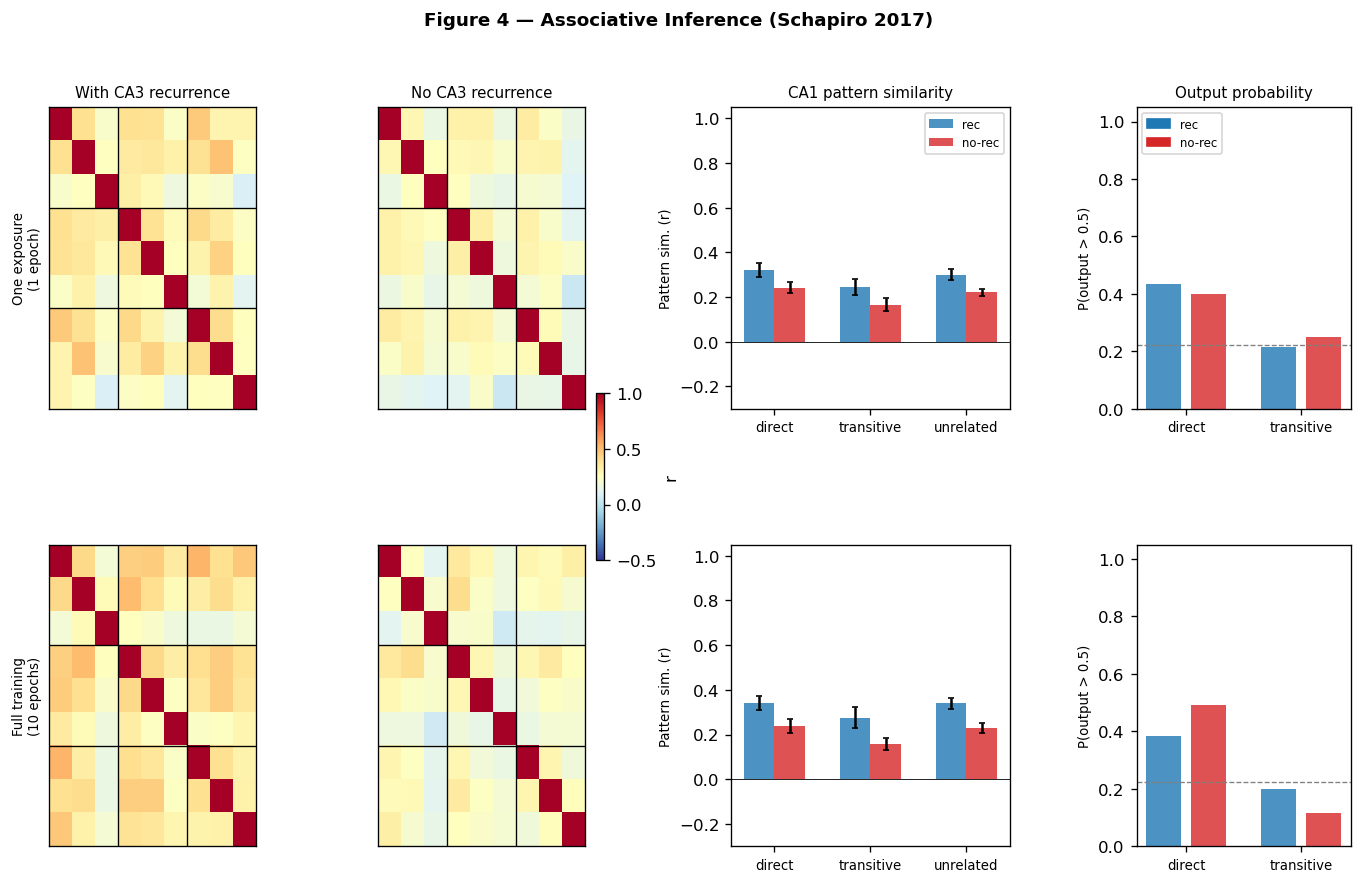

In [14]:
# --- Plot Figure 4 — Associative Inference (Schapiro 2017 Fig. 4) ---
# Layout: 2 rows (one-exposure / full training) × 4 panels per row
# Col 0: CA1 RSA with CA3 recurrence (settled)
# Col 1: CA1 RSA without CA3 recurrence (settled)
# Col 2: pattern similarity bars (direct / transitive / unrelated; rec vs norec)
# Col 3: output probability bars (direct / transitive; rec vs norec)

from matplotlib.patches import Patch

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.55,
                         width_ratios=[1, 1, 1.3, 1.0])

conditions = [
    ('One exposure\n(1 epoch)',
     chain_1exp_rec_rsa, chain_1exp_norec_rsa,
     exp1_rec_sim, exp1_norec_sim,
     exp1_rec_prob, exp1_norec_prob),
    ('Full training\n(10 epochs)',
     chain_full_rec_rsa, chain_full_norec_rsa,
     full_rec_sim, full_norec_sim,
     full_rec_prob, full_norec_prob),
]

last_im = None
for row, (label, rec_rsa, norec_rsa, rec_sim, norec_sim, rec_prob, norec_prob) in enumerate(conditions):

    # Col 0: CA1 RSA with recurrence
    ax0 = fig.add_subplot(gs[row, 0])
    last_im = plot_rsa_heatmap(ax0, rec_rsa['ca1'].mean(0), N_TRIADS, IPC_CHAIN,
                                title='With CA3 recurrence' if row == 0 else None,
                                ylabel=label)

    # Col 1: CA1 RSA without recurrence
    ax1 = fig.add_subplot(gs[row, 1])
    plot_rsa_heatmap(ax1, norec_rsa['ca1'].mean(0), N_TRIADS, IPC_CHAIN,
                     title='No CA3 recurrence' if row == 0 else None)

    # Shared colorbar after both RSA panels in row 1
    if row == 1:
        plt.colorbar(last_im, ax=[fig.axes[0], fig.axes[1], fig.axes[4], fig.axes[5]],
                     fraction=0.015, pad=0.02, label='r')

    # Col 2: pattern similarity bars for CA1 — direct / transitive / unrelated
    ax2 = fig.add_subplot(gs[row, 2])
    cats = ['direct', 'transitive', 'unrelated']
    x, w = np.arange(len(cats)), 0.32
    for j, (sim, col, lbl) in enumerate([(rec_sim, 'C0', 'rec'), (norec_sim, 'C3', 'no-rec')]):
        vals = [sim['ca1'][c][0] for c in cats]
        errs = [sim['ca1'][c][1] for c in cats]
        ax2.bar(x + (j - 0.5) * w, vals, width=w, color=col, alpha=0.8,
                label=lbl if row == 0 else '')
        for xi, (m, se) in zip(x + (j - 0.5) * w, zip(vals, errs)):
            ax2.errorbar(xi, m, yerr=se, fmt='none', color='k', capsize=2)
    ax2.set_xticks(x)
    ax2.set_xticklabels(cats, fontsize=8)
    ax2.axhline(0, color='k', lw=0.5)
    ax2.set_ylabel('Pattern sim. (r)', fontsize=8)
    ax2.set_ylim(-0.3, 1.05)
    if row == 0:
        ax2.set_title('CA1 pattern similarity', fontsize=9)
        ax2.legend(fontsize=7)

    # Col 3: output probability bars (direct / transitive; rec vs norec side by side)
    ax3 = fig.add_subplot(gs[row, 3])
    x_bars = [0, 0.7, 1.8, 2.5]
    heights = [rec_prob['direct'], norec_prob['direct'],
               rec_prob['transitive'], norec_prob['transitive']]
    colors  = ['C0', 'C3', 'C0', 'C3']
    ax3.bar(x_bars, heights, width=0.55, color=colors, alpha=0.8)
    ax3.set_xticks([0.35, 2.15])
    ax3.set_xticklabels(['direct', 'transitive'], fontsize=8)
    ax3.set_ylabel('P(output > 0.5)', fontsize=8)
    ax3.axhline(2 / N_ITEMS_CHAIN, color='gray', lw=0.8, ls='--', label='chance')
    ax3.set_ylim(0, 1.05)
    if row == 0:
        ax3.set_title('Output probability', fontsize=9)
        ax3.legend(handles=[Patch(color='C0', label='rec'),
                             Patch(color='C3', label='no-rec')],
                   fontsize=7, loc='upper left')

fig.suptitle('Figure 4 — Associative Inference (Schapiro 2017)', fontsize=11, fontweight='bold')
plt.savefig(DIR_VIZ / 'Schapiro2017_Fig4_inference.png', dpi=150, bbox_inches='tight')
plt.show()